<a href="https://colab.research.google.com/github/rachtorr/compass/blob/main/R_Geospatial_CPH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Introduction to Geospatial Data in R

 This workshop covers how to open, work with, and plot raster-format spatial data in R. We will answer the following questions:

- What is a raster dataset?
- How do I work with and plot raster data in R?
- How can I handle missing data values for a raster?

It is helpful to have some knowledge of R, or any programming language, but not necessary.

[See details on the full lesson from Data Carpentries here](https://datacarpentry.github.io/r-raster-vector-geospatial/index.html).

If you want to save the changes you make, be sure to make a copy of this notebook!

Shortcut url: [hum.link/R_geospatial](https://hum.link/R_geospatial)

In [ ]:
# this is taking a real long time ~ 8 minutes. It will be shorter if working in Rstudio. Go ahead and click run and we can do introductions and an overview of this page
install.packages("terra")
install.packages("ggplot2")
install.packages("dplyr")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(terra)
library(ggplot2)
library(dplyr)

terra 1.9.11


Attaching package: ‘dplyr’


The following objects are masked from ‘package:terra’:

    intersect, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




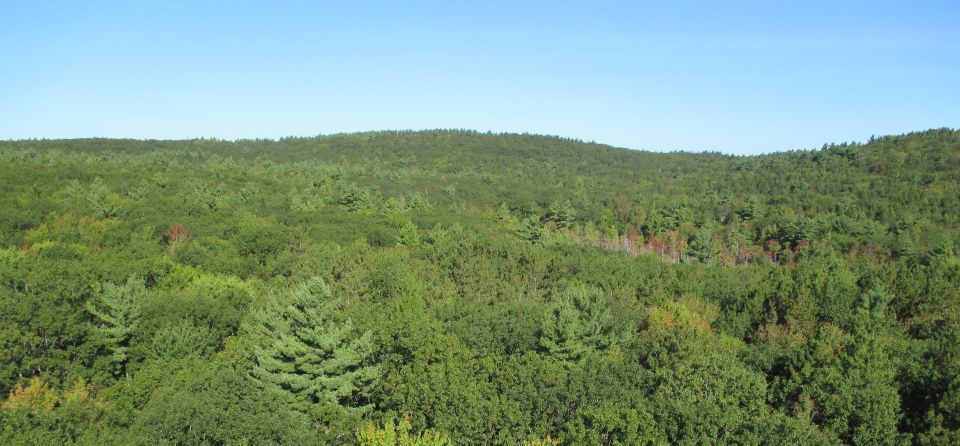
##  NEON Data

The data and lessons in this workshop were originally developed through a hackathon funded by the National Ecological Observatory Network (NEON) - an NSF funded observatory in Boulder, Colorado - in collaboration with Data Carpentry, SESYNC and CYVERSE. NEON is collecting data for 30 years to help scientists understand how our aquatic and terrestrial ecosystems are changing. The data used in these lessons cover two NEON field sites:

- Harvard Forest (HARV) - Massachusetts, USA
- San Joaquin Experimental Range (SJER) - California, USA

More information about this dataset can be found [here](https://datacarpentry.github.io/geospatial-workshop/data).

We will download this data in the next step.

### Airborne Remote Sensing data

Remote sensing data is any observations from a distance! A lot of remote sensing is collected via satellite, but there are other methods like airplanes and drones. In this case, a light aircraft collected high resolution data from low altitudes.

We will be looking at LiDAR data collected by the NEON Airborne Observation Platform (AOP) and processed at NEON including a canopy height model, digital elevation model and digital surface model for NEON’s Harvard Forest and San Joaquin Experimental Range field sites.

### Digital surface model

A digital surface model includes elevation as well as the height of any structures such as buildings and trees. Read more about different types of elevation models [here](https://gisgeography.com/dem-dsm-dtm-differences/).

In [ ]:
# Download link
url <- "https://ndownloader.figshare.com/articles/2009586/versions/10"
# name of file to download to
destfile="RGeospatial.zip"

# download file
options(timeout = 300)  # increase timeout for large files
download.file(url, destfile, mode = "wb", method = "curl")

In [ ]:
# unzip folders to access tif file
unzip('RGeospatial.zip', exdir = "data_folder")

unzip("data_folder/NEON-DS-Airborne-Remote-Sensing.zip")

## Terra package

There are many packages in R for working with spatial data, here we focus on using `terra`. Terra allows you to visualize and analyze spatial data in raster or vector format.

[Learn more about terra here](https://rspatial.github.io/terra/index.html)

In [ ]:
describe("NEON-DS-Airborne-Remote-Sensing/HARV/DSM/HARV_dsmCrop.tif")

[1] "Driver: GTiff/GeoTIFF"                                                                                                                                                                                                                                                          
 [2] "Files: /content/NEON-DS-Airborne-Remote-Sensing/HARV/DSM/HARV_dsmCrop.tif"                                                                                                                                                                                                      
 [3] "Size is 1697, 1367"                                                                                                                                                                                                                                                             
 [4] "Coordinate System is:"                                                                                                                                                                                                                                                          
 [5] "PROJCRS[\"WGS 84 / UTM zone 18N\","                                                                                                                                                                                                                                             
 [6] "    BASEGEOGCRS[\"WGS 84\","                                                                                                                                                                                                                                                    
 [7] "        DATUM[\"World Geodetic System 1984\","                                                                                                                                                                                                                                  
 [8] "            ELLIPSOID[\"WGS 84\",6378137,298.257223563,"                                                                                                                                                                                                                        
 [9] "                LENGTHUNIT[\"metre\",1]]],"                                                                                                                                                                                                                                     
[10] "        PRIMEM[\"Greenwich\",0,"                                                                                                                                                                                                                                                
[11] "            ANGLEUNIT[\"degree\",0.0174532925199433]],"                                                                                                                                                                                                                         
[12] "        ID[\"EPSG\",4326]],"                                                                                                                                                                                                                                                    
[13] "    CONVERSION[\"UTM zone 18N\","                                                                                                                                                                                                                                               
[14] "        METHOD[\"Transverse Mercator\","                                                                                                                                                                                                                                        
[15] "            ID[\"EPSG\",9807]],"                                                         

In [ ]:
### live coding starts here

## Plotting raster

We will spend time using `ggplot` and `geom_raster()` to plot our raster.

*   [Learn more about ggplot here](https://ggplot2.tidyverse.org/)
*   [Learn more about viridis color scale here](https://cran.r-project.org/web/packages/viridis/vignettes/intro-to-viridis.html)



In [ ]:
## practice ggplot here

## Understanding Projections and CRS

The CRS for our data is given to us by R in proj4 format. Let’s break down the pieces of proj4 string. The string contains all of the individual CRS elements that R or another GIS might need. Each element is specified with a + sign, similar to how a .csv file is delimited or broken up by a ,. After each + we see the CRS element being defined. For example projection (proj=) and datum (datum=).

UTM Proj4 String
A projection string (like the one of dsm_harv) specifies the UTM projection as follows:

+proj=utm +zone=18 +datum=WGS84 +units=m +no_defs +ellps=WGS84 +towgs84=0,0,0

proj=utm: the projection is UTM, UTM has several zones.
zone=18: the zone is 18
datum=WGS84: the datum is WGS84 (the datum refers to the 0,0 reference for the coordinate system used in the projection)
units=m: the units for the coordinates are in meters
ellps=WGS84: the ellipsoid (how the earth’s roundness is calculated) for the data is WGS84
Note that the zone is unique to the UTM projection. Not all CRSs will have a zone. Image source: Chrismurf at English Wikipedia, via Wikimedia Commons (CC-BY).

Utm-zones-USA.svg

In [ ]:
# crs function here

## Raster bands

The Digital Surface Model object (dsm_harv) that we’ve been working with is a single band raster. This means that there is only one dataset stored in the raster: surface elevation in meters for one time period.

A raster dataset can contain one or more bands. We can use the rast() function to import one single band from a single or multi-band raster. We can view the number of bands in a raster using the nlyr() function.

However, raster data can also be multi-band, meaning that one raster file contains data for more than one variable or time period for each cell. Jump to a later episode in this series for information on working with multi-band rasters: Work with Multi-band Rasters in R.

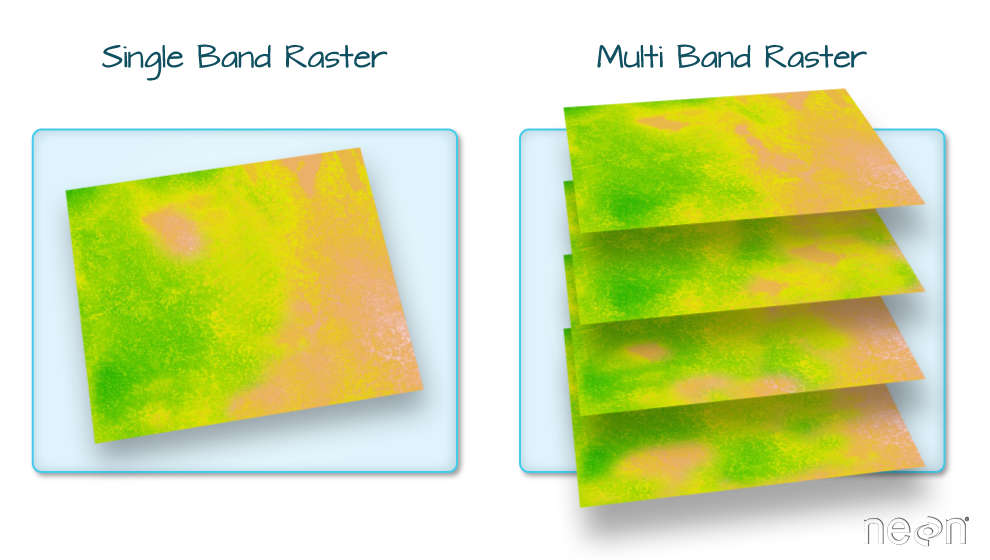

In [ ]:
# type function here to check how many bands are in our raster

## Check for missing values

Raster data often has a NoDataValue associated with it. This is a value assigned to pixels where data is missing or no data were collected.

By default the shape of a raster is always rectangular. So if we have a dataset that has a shape that isn’t rectangular, some pixels at the edge of the raster will have NoDataValues. This often happens when the data were collected by an airplane which only flew over some part of a defined region.

The value that is conventionally used to take note of missing data (the NoDataValue value) varies by the raster data type. For floating-point rasters, the figure -3.4e+38 is a common default, and for integers, -9999 is common. Some disciplines have specific conventions that vary from these common values.

In some cases, other NA values may be more appropriate. An NA value should be a) outside the range of valid values, and b) a value that fits the data type in use. For instance, if your data ranges continuously from -20 to 100, 0 is not an acceptable NA value! Or, for categories that number 1-15, 0 might be fine for NA, but using -.000003 will force you to save the GeoTIFF on disk as a floating point raster, resulting in a bigger file.

If we are lucky, our GeoTIFF file has a tag that tells us what is the NoDataValue. If we are less lucky, we can find that information in the raster’s metadata. If a NoDataValue was stored in the GeoTIFF tag, when R opens up the raster, it will assign each instance of the value to NA. Values of NA will be ignored by R as demonstrated above.

- How can we check for NA in our `dsm_HARV` data?
- How do we know what represents NA in our data?

In [ ]:
# type code here

## SJER

If we have time, let's repeat the process of exploring and plotting the dsm for SJER location

In [ ]:
dsm_SJER = rast("/content/NEON-DS-Airborne-Remote-Sensing/SJER/DSM/SJER_dsmCrop.tif")

## Tutorial

Full code from our live tutorial is below

In [ ]:
# make sure to install packages first
#

library(terra)
library(ggplot2)
library(dplyr)


dsm_harv <- rast("NEON-DS-Airborne-Remote-Sensing/HARV/DSM/HARV_dsmCrop.tif")

summary(dsm_harv)

# force R to use all data
summary(values(dsm_harv))

# terra function to see min and max
minmax(dsm_harv)

# distribution
hist(values(dsm_harv))

# quick plot
plot(dsm_harv)

## plot with ggplot
# convert to data frame
dsm_harv_df <- as.data.frame(dsm_harv, xy=TRUE)
# preview df
str(dsm_harv_df)
# preview first six rows
head(dsm_harv_df)

# ggplot
ggplot(dsm_harv_df) +
  geom_raster(aes(x=x, y=y, fill=HARV_dsmCrop)) +
  scale_fill_viridis_c(option="plasma") +
  labs(x="lon", y= "lat", title="Harvard DSM", subtitle="NEON data") +
  coord_quickmap()

# check coordinate reference system
crs(dsm_harv, proj=T)

# check how many bands
nlyr(dsm_harv)

# check for missing values
describe(dsm_harv)

sum(is.na(dsm_harv_df))

# layer with hillshade
dsm_harv_hill <- rast("NEON-DS-Airborne-Remote-Sensing/HARV/DSM/HARV_DSMhill.tif")

# preview
summary(dsm_harv_hill)
# quick plot
plot(dsm_harv_hill)

# convert to df
dsm_harv_hill_df <- as.data.frame(dsm_harv_hill, xy=TRUE)

ggplot() +
  geom_raster(data=dsm_harv_df,
              aes(x=x, y=y, fill=HARV_dsmCrop)) +
  geom_raster(data=dsm_harv_hill_df,
              aes(x=x, y=y, alpha=HARV_DSMhill)) +
  scale_fill_viridis_c() +
  scale_alpha(range = c(0.15, 0.65), guide="none") +
  coord_quickmap() +
  ggtitle("elevation with hillshade, Harvard forest")

